In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# load dataset
df = pd.read_csv('House Price Prediction Dataset.csv')

In [3]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [5]:
df.shape

(2000, 10)

In [6]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


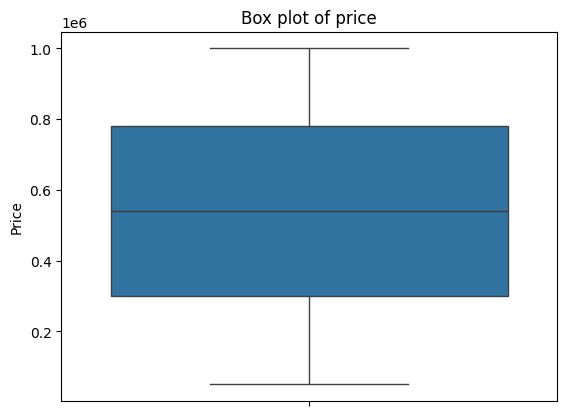

In [9]:
# outlier detection
sns.boxplot(df['Price'])
plt.title('Box plot of price')
plt.show()

In [10]:
# checking all the object columns in the dataset
df.select_dtypes(include=['object']).columns

Index(['Location', 'Condition', 'Garage'], dtype='object')

In [12]:
# to make the object columns into integer we encode them
le = LabelEncoder()
df['Location'] = le.fit_transform(df['Location'])
df['Condition'] = le.fit_transform(df['Condition'])
df['Garage'] = le.fit_transform(df['Garage'])

In [13]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,149919
1,2,4272,5,4,3,1958,0,0,0,424998
2,3,3592,2,2,3,1938,0,2,0,266746
3,4,966,4,2,2,1902,2,1,1,244020
4,5,4926,1,4,2,1975,0,1,1,636056


In [15]:
# noe splitting data on the basis of price
X = df.drop('Price' ,axis=1)
Y = df['Price']

In [19]:
# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.731185   -1.10147065  1.40179052 ... -1.2743323  -1.31626723
  -0.96269532]
 [-1.72945295  1.14748543  1.40179052 ... -1.2743323  -1.31626723
  -0.96269532]
 [-1.7277209   0.62231712 -0.70458141 ... -1.2743323   0.46007181
  -0.96269532]
 ...
 [ 1.7277209  -1.33161794  1.40179052 ... -0.39396456  1.34824133
  -0.96269532]
 [ 1.72945295  0.9853011  -0.00245743 ...  1.36677091 -1.31626723
   1.03875025]
 [ 1.731185    0.15661639  1.40179052 ...  0.48640317 -0.42809771
  -0.96269532]]


In [20]:
# train test split
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled,Y, test_size=0.2, random_state=42)

In [21]:
# training the model
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [24]:
#preduction
Y_pred = model.predict(X_test)
print(Y_pred)

[499892.68770246 547716.21146815 497957.44144647 561541.78039275
 569998.440012   544238.11836566 548067.19232473 537518.27659545
 573196.90589927 564290.4839245  555490.23241835 565168.5239704
 493064.13061795 539246.99002186 526117.96389235 542184.97859064
 558685.81245856 563989.74390433 550694.15759842 501264.10226999
 543945.46670858 522239.47100192 514970.34835556 570820.18410533
 543724.37927387 544023.47473184 513523.25592726 518365.08994128
 534499.41847968 511945.59764146 499406.00437324 548021.78053986
 548031.46904337 571333.76866662 523515.72222078 495271.37428654
 559732.53546688 580117.4513599  514816.74894965 517239.50417612
 510600.59982215 510965.96252017 531049.27747674 543985.25299021
 539819.50381511 545007.50337119 565908.72333969 525109.11878556
 562866.74806625 533798.01162729 493295.51182402 540818.0916496
 556484.86905216 550517.25847893 524878.06467552 512275.11639793
 563580.13099719 484850.90272967 503959.74110148 531194.84988708
 536726.10388918 513895.546

In [27]:
# model evaqluation
mse = mean_squared_error(Y_test,Y_pred)
mae = mean_absolute_error(Y_test,Y_pred)
r2 = r2_score(Y_test,Y_pred)
print('Mean Squared Error:',mse)
print('Mean Absolute Error:',mae)
print('R2 score:',r2)
print('Root Mean Squared Error:',np.sqrt(mse))

Mean Squared Error: 78663273949.43434
Mean Absolute Error: 244003.46389812755
R2 score: -0.011111291082151142
Root Mean Squared Error: 280469.73802789196


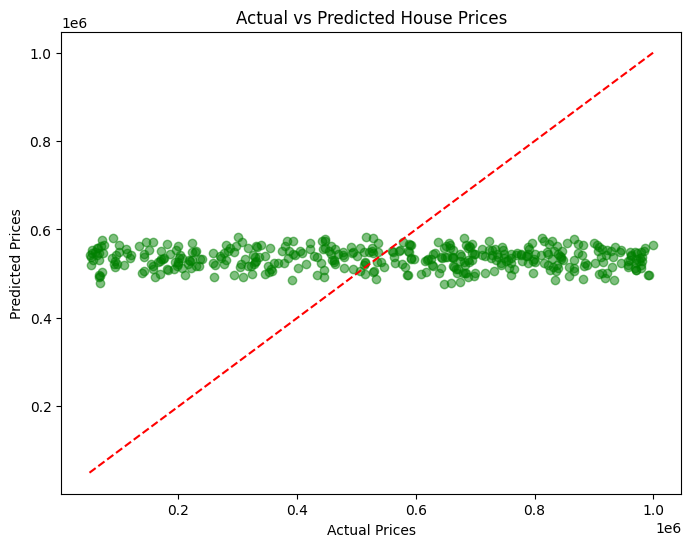

In [31]:
3#plotting the graph
plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_pred, alpha = 0.5,  color='green')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], '--r')
plt.show()